## 2. SVM

### 完整的 SVM 分類流程 + 資料切分 + 評估指標

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. 讀資料
df = pd.read_csv("mobile_price.csv")

# 2. 分 X / y
X = df.drop("price_range", axis=1)
y = df["price_range"]

# 3. 先切 train (60%) 和 temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)

# 4. 再把 temp 切成 validation (20%) + test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 5. 建立 SVM 模型
model = SVC(C=1.0)

# 6. 訓練
model.fit(X_train, y_train)

# 7. 預測
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# 8. 計算 metrics
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} F1-score: {f1:.4f}")
    print("------")

evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

Train Accuracy: 0.9450
Train F1-score: 0.9445
------
Validation Accuracy: 0.9450
Validation F1-score: 0.9448
------
Test Accuracy: 0.9575
Test F1-score: 0.9573
------


### Hyperparameter Tuning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 讀資料
df = pd.read_csv("mobile_price.csv")
X = df.drop("price_range", axis=1)
y = df["price_range"]

# 切資料 (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# C values
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# 紀錄結果
train_acc, val_acc, test_acc = [], [], []
train_f1, val_f1, test_f1 = [], [], []

for C in C_values:
    model = SVC(C=C)
    model.fit(X_train, y_train)

    # 預測
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_val, y_val_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

    # f1
    train_f1.append(f1_score(y_train, y_train_pred, average='weighted'))
    val_f1.append(f1_score(y_val, y_val_pred, average='weighted'))
    test_f1.append(f1_score(y_test, y_test_pred, average='weighted'))

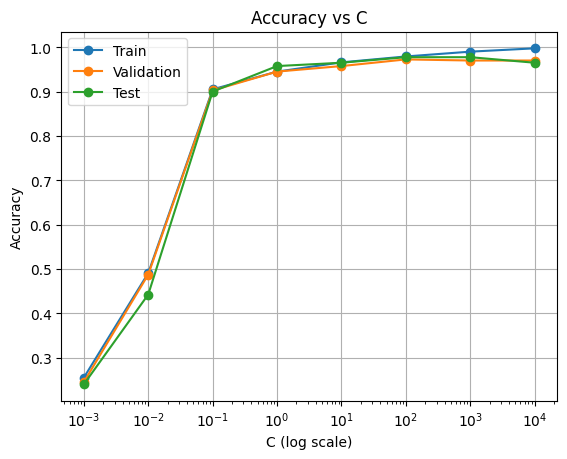

In [3]:
plt.figure()
plt.plot(C_values, train_acc, marker='o', label='Train')
plt.plot(C_values, val_acc, marker='o', label='Validation')
plt.plot(C_values, test_acc, marker='o', label='Test')

plt.xscale('log')  # 很重要！
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs C')
plt.legend()
plt.grid(True)

plt.show()

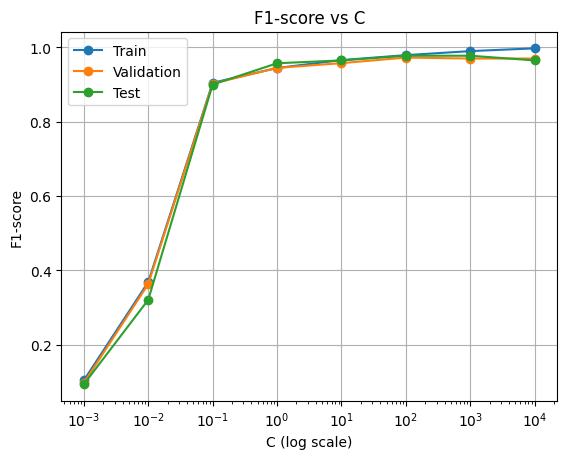

In [4]:
plt.figure()
plt.plot(C_values, train_f1, marker='o', label='Train')
plt.plot(C_values, val_f1, marker='o', label='Validation')
plt.plot(C_values, test_f1, marker='o', label='Test')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1-score')
plt.title('F1-score vs C')
plt.legend()
plt.grid(True)

plt.show()

In [5]:
results = pd.DataFrame({
    "C": C_values,
    "Train Acc": train_acc,
    "Val Acc": val_acc,
    "Test Acc": test_acc,
    "Train F1": train_f1,
    "Val F1": val_f1,
    "Test F1": test_f1
})

print(results)

           C  Train Acc  Val Acc  Test Acc  Train F1    Val F1   Test F1
0      0.001   0.255000   0.2450    0.2400  0.103625  0.096426  0.092903
1      0.010   0.490833   0.4875    0.4425  0.368342  0.362820  0.320378
2      0.100   0.905000   0.9025    0.9000  0.904724  0.902429  0.899996
3      1.000   0.945000   0.9450    0.9575  0.944525  0.944814  0.957272
4     10.000   0.965833   0.9575    0.9650  0.965776  0.957543  0.964960
5    100.000   0.979167   0.9725    0.9775  0.979170  0.972611  0.977554
6   1000.000   0.990000   0.9700    0.9775  0.989992  0.969976  0.977538
7  10000.000   0.997500   0.9700    0.9650  0.997500  0.970026  0.964963


In [6]:
best_idx = val_acc.index(max(val_acc))
best_C = C_values[best_idx]

print("Best C:", best_C)
print("Best Validation Accuracy:", val_acc[best_idx])

Best C: 100
Best Validation Accuracy: 0.9725


## 3. Association Rule Mining 

### FP-growth algorithm

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# 讀取資料
df = pd.read_csv("mobile_price.csv")

# 只保留 price_range = 1 的資料
df_1 = df[df["price_range"] == 1].copy()

# 指定要使用的特徵
features = ["ram", "int_memory", "px_width", "battery_power"]

# 將每個 feature 分成 low / medium / high
for col in features:
    min_val = df_1[col].min()
    max_val = df_1[col].max()
    value_range = max_val - min_val

    low_threshold = min_val + value_range * 0.3
    high_threshold = min_val + value_range * 0.7

    def categorize(x):
        if x <= low_threshold:
            return f"{col}_low"
        elif x <= high_threshold:
            return f"{col}_medium"
        else:
            return f"{col}_high"

    df_1[col + "_cat"] = df_1[col].apply(categorize)

# 轉成 transaction format
transactions = df_1[[col + "_cat" for col in features]].values.tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(te_array, columns=te.columns_)

# 使用 FP-growth 找 frequent patterns
frequent_patterns = fpgrowth(
    transaction_df,
    min_support=0.3,
    use_colnames=True
)

# 依 support 由高到低排序
frequent_patterns = frequent_patterns.sort_values(
    by="support",
    ascending=False
)

# 顯示結果
print(frequent_patterns)

   support                                       itemsets
2    0.682                        frozenset({ram_medium})
3    0.416                   frozenset({px_width_medium})
5    0.414              frozenset({battery_power_medium})
4    0.412                 frozenset({int_memory_medium})
7    0.318  frozenset({ram_medium, battery_power_medium})
0    0.316                    frozenset({int_memory_low})
1    0.308                 frozenset({battery_power_low})
6    0.306       frozenset({px_width_medium, ram_medium})


In [8]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 讀取資料
df = pd.read_csv("mobile_price.csv")

# 只保留 price_range = 1 的資料
df_1 = df[df["price_range"] == 1].copy()

# 指定特徵
features = ["ram", "int_memory", "px_width", "battery_power"]

# 特徵分群：low / medium / high (3:4:3)
for col in features:
    min_val = df_1[col].min()
    max_val = df_1[col].max()
    value_range = max_val - min_val

    low_threshold = min_val + value_range * 0.3
    high_threshold = min_val + value_range * 0.7

    def categorize(x):
        if x <= low_threshold:
            return f"{col}_low"
        elif x <= high_threshold:
            return f"{col}_medium"
        else:
            return f"{col}_high"

    df_1[col + "_cat"] = df_1[col].apply(categorize)

# 建立 transaction records
transactions = df_1[[col + "_cat" for col in features]].values.tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(te_array, columns=te.columns_)

# FP-growth 找 frequent patterns
frequent_patterns = fpgrowth(
    transaction_df,
    min_support=0.3,
    use_colnames=True
)

# 產生 association rules
rules = association_rules(
    frequent_patterns,
    metric="confidence",
    min_threshold=0.4
)

# 篩選條件
rules_filtered = rules[
    (rules["support"] >= 0.3) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 0.8)
]

# 只保留重要欄位
rules_filtered = rules_filtered[
    ["antecedents", "consequents",
     "support", "confidence", "lift"]
]

# 依 confidence 排序
rules_filtered = rules_filtered.sort_values(
    by="confidence",
    ascending=False
)

# 顯示結果
print(rules_filtered)

                         antecedents                        consequents  \
3  frozenset({battery_power_medium})            frozenset({ram_medium})   
0       frozenset({px_width_medium})            frozenset({ram_medium})   
2            frozenset({ram_medium})  frozenset({battery_power_medium})   
1            frozenset({ram_medium})       frozenset({px_width_medium})   

   support  confidence      lift  
3    0.318    0.768116  1.126270  
0    0.306    0.735577  1.078559  
2    0.318    0.466276  1.126270  
1    0.306    0.448680  1.078559  


In [9]:
for idx, row in rules_filtered.iterrows():
    print(f"{set(row['antecedents'])} -> {set(row['consequents'])}")
    print(f"support = {row['support']:.3f}, "
          f"confidence = {row['confidence']:.3f}, "
          f"lift = {row['lift']:.3f}")
    print("-" * 50)

{'battery_power_medium'} -> {'ram_medium'}
support = 0.318, confidence = 0.768, lift = 1.126
--------------------------------------------------
{'px_width_medium'} -> {'ram_medium'}
support = 0.306, confidence = 0.736, lift = 1.079
--------------------------------------------------
{'ram_medium'} -> {'battery_power_medium'}
support = 0.318, confidence = 0.466, lift = 1.126
--------------------------------------------------
{'ram_medium'} -> {'px_width_medium'}
support = 0.306, confidence = 0.449, lift = 1.079
--------------------------------------------------


## 4. PCA and K-Means

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 讀取資料
df = pd.read_csv("mobile_price.csv")

# features (X)
X = df.drop("price_range", axis=1)
# label (y)
y = df["price_range"]

# z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 查看結果
print("Features shape:", X_scaled.shape)
print("Labels shape:", y.shape)

# 顯示前 5 筆標準化後資料
print(X_scaled[:5])

Features shape: (2000, 20)
Labels shape: (2000,)
[[-0.90259726 -0.9900495   0.83077942 -1.01918398 -0.76249466 -1.04396559
  -1.38064353  0.34073951  1.34924881 -1.10197128 -1.3057501  -1.40894856
  -1.14678403  0.39170341 -0.78498329  0.2831028   1.46249332 -1.78686097
  -1.00601811  0.98609664]
 [-0.49513857  1.0100505  -1.2530642   0.98117712 -0.99289039  0.95788598
   1.15502422  0.68754816 -0.12005944 -0.66476784 -0.64598879  0.58577791
   1.70446468  0.46731702  1.11426556 -0.63531667 -0.73426721  0.55964063
   0.99401789 -1.01409939]
 [-1.5376865   1.0100505  -1.2530642   0.98117712 -0.53209893  0.95788598
   0.49354568  1.38116548  0.13424391  0.20963905 -0.64598879  1.39268422
   1.07496821  0.44149774 -0.31017108 -0.86492153 -0.36814045  0.55964063
   0.99401789 -1.01409939]
 [-1.41931861  1.0100505   1.19851653 -1.01918398 -0.99289039 -1.04396559
  -1.2152739   1.03435682 -0.26133908  0.6468425  -0.15116781  1.28674959
   1.23697097  0.59456919  0.87685946  0.51270767 -0.002

### PCA

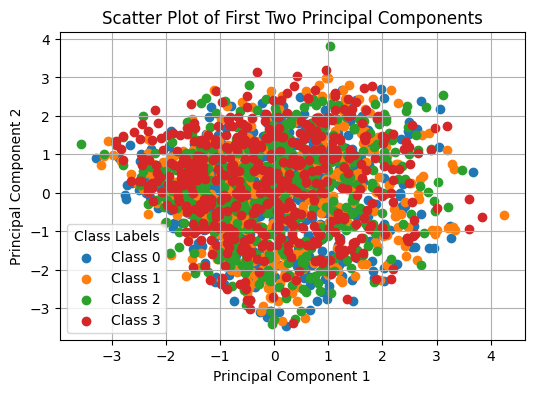

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA 降維到 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 畫 scatter plot（不同類別不同顏色）
plt.figure(figsize=(6,4))

for label in sorted(y.unique()):
    plt.scatter(
        X_pca[y == label, 0], 
        X_pca[y == label, 1], 
        label=f"Class {label}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot of First Two Principal Components")
plt.legend(title="Class Labels")
plt.grid(True)
plt.show()

Adjusted Rand Index (ARI): 0.005262653552611806


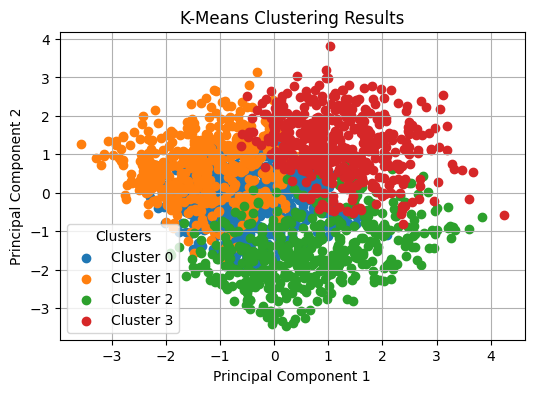

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

# K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 評估 clustering performance
ari_score = adjusted_rand_score(y, cluster_labels)
print("Adjusted Rand Index (ARI):", ari_score)

# Scatter plot visualization
plt.figure(figsize=(6,4))

for cluster in range(4):
    plt.scatter(
        X_pca[cluster_labels == cluster, 0],
        X_pca[cluster_labels == cluster, 1],
        label=f"Cluster {cluster}",
    )

plt.title("K-Means Clustering Results")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Clusters")
plt.grid(True)

plt.show()

Adjusted Rand Index (ARI): 0.0018818698484641605


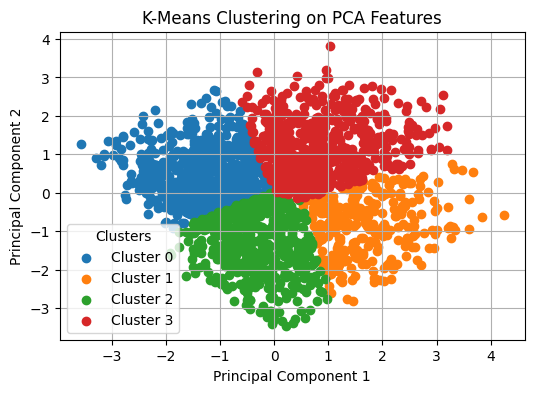

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

# 使用 PCA 後的 2-dimensional features 做 K-Means
kmeans_pca = KMeans(n_clusters=4, random_state=0, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

# 評估 clustering performance
ari_score_pca = adjusted_rand_score(y, cluster_labels_pca)
print("Adjusted Rand Index (ARI):", ari_score_pca)

# 視覺化 clustering results
plt.figure(figsize=(6,4))

for cluster in range(4):
    plt.scatter(
        X_pca[cluster_labels_pca == cluster, 0],
        X_pca[cluster_labels_pca == cluster, 1],
        label=f"Cluster {cluster}",
    )

plt.title("K-Means Clustering on PCA Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Clusters")
plt.grid(True)

plt.show()